# Task:

    1. Define new training preparation based on TransfomrerCPDNewView
    2. Train and Test model
    nn.BCELoss() -> for binary output vector

# Import libs

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm import tqdm
from IPython.display import clear_output
from sklearn.preprocessing import normalize
from sklearn.preprocessing import scale

from torch.utils.data import DataLoader, Dataset

In [2]:
import sys

sys.path.append("../..")

In [5]:
from src.data.SythData import RandomChangePointsGenerator
# from src.models.SubspaceBased.SingularSequenceTransformer import SingularSequenceTransformer

In [68]:
class RandomChangePointsGenerator:
    """Improved version that distributes change points more uniformly"""
    
    def __init__(self,
                 seed: Optional[int] = None,
                 cps_number: int = 0,
                 length_data: int = 24 * 7 * 15 + 15,
                 minimum_sequence_cp: int = 10,
                 start_mutation_coeff: float = 0.5,
                 treshold_mutation_coeff: float = 0.1,
                 power_coeff: float = 1.2,
                 attemps_to_failure: int = 15):
        
        if seed is None:
            seed = np.random.randint(low=0, high=65535)
        np.random.seed(seed)
        
        self.seed = seed
        self.cps_number = cps_number
        self.length_data = length_data
        self.power_coeff = power_coeff
        self.start_mutation_coeff = start_mutation_coeff
        self.treshold_mutation_coeff = treshold_mutation_coeff
        self.minimum_sequence_cp = minimum_sequence_cp
        self.attemps_to_failure = attemps_to_failure

        if cps_number < 0:
            raise AttributeError(f"Change points number has to be positive! However, you set it to be {cps_number}")

        if length_data < 10:
            raise NotImplementedError("This class expects to generate array with more than 10 values in a sequence!")

        if (length_data / (cps_number + 1e-9)) < minimum_sequence_cp:
            raise NotImplementedError("Expected length of data is too small for expected cps_number! One of your "
                                   "sequences could be less than minimum_sequence_cp points which may lead to errors.")

    def _new_mutation_coeff(self, sequence_len: int) -> float:
        """Generate random float value between 0 and 1."""
        if sequence_len ** self.power_coeff > self.length_data:
            out = np.random.random() - self.treshold_mutation_coeff
        else:
            out = np.random.random()
        return out

    def _is_mutation_apply(self, sequence_len: int, past_mutation_coeff: float) -> bool:
        """Determine if we should apply mutation factor"""
        if sequence_len > self.minimum_sequence_cp:
            # Adjust probability based on position in sequence to encourage uniform distribution
            position_factor = sequence_len / self.length_data
            adjusted_prob = past_mutation_coeff * (1 + position_factor)
            return np.random.random() > adjusted_prob
        return False

    def queue(self, queue_window: int, time_series: np.array) -> np.array:
        """Ensure minimum distance between change points"""
        cp_indices = np.where(time_series == 1)[0]
        for i in range(1, len(cp_indices)):
            if cp_indices[i] - cp_indices[i-1] < queue_window:
                # Remove the latter change point if too close
                time_series[cp_indices[i]] = 0
        return time_series

    def generate_uniform_change_points(self) -> np.array:
        """Generate change points with more uniform distribution"""
        cps_array = np.zeros(self.length_data)
        
        if self.cps_number == 0:
            return cps_array
            
        # Calculate ideal spacing between change points
        ideal_spacing = self.length_data / (self.cps_number + 1)
        
        # Generate initial positions with some randomness
        positions = [int(i + 1 + np.random.uniform(-0.3, 0.3)) * ideal_spacing for i in range(self.cps_number)]
        positions = np.clip(positions, self.minimum_sequence_cp, self.length_data - self.minimum_sequence_cp)
        
        # Convert to integers and ensure uniqueness
        positions = np.unique(np.round(positions).astype(int))
        
        # If we didn't get enough points, add more randomly
        while len(positions) < self.cps_number:
            new_pos = np.random.randint(self.minimum_sequence_cp, 
                                      self.length_data - self.minimum_sequence_cp)
            if np.min(np.abs(positions - new_pos)) > self.minimum_sequence_cp:
                positions = np.append(positions, new_pos)
        
        # Ensure minimum distance
        positions.sort()
        for i in range(1, len(positions)):
            if positions[i] - positions[i-1] < self.minimum_sequence_cp:
                positions[i] = positions[i-1] + self.minimum_sequence_cp
        
        cps_array[positions] = 1
        return cps_array

    def generate_change_points_with_mutation(self) -> np.array:
        """Main function to generate array of change points with uniform distribution"""
        # First try uniform generation
        cps_array = self.generate_uniform_change_points()
        
        # If we didn't get enough points, fall back to random
        if sum(cps_array) < self.cps_number:
            attempts = 0
            while sum(cps_array) < self.cps_number and attempts < self.attemps_to_failure:
                pos = np.random.randint(self.minimum_sequence_cp, 
                                      self.length_data - self.minimum_sequence_cp)
                # Check distance from existing points
                existing = np.where(cps_array == 1)[0]
                if len(existing) == 0 or np.min(np.abs(existing - pos)) > self.minimum_sequence_cp:
                    cps_array[pos] = 1
                attempts += 1
        
        # Final check and queue filtering
        cps_array = self.queue(self.minimum_sequence_cp, cps_array)
        
        if sum(cps_array) < self.cps_number:
            print(f"Warning: Only generated {sum(cps_array)} change points out of requested {self.cps_number}")
            
        return cps_array

    def generate_change_points_with_random(self, cps_array: Optional[np.array] = None) -> np.array:
        """Alternative method using random generation with uniform distribution"""
        if cps_array is None:
            cps_array = np.zeros(self.length_data)
            
        positions = []
        attempts = 0
        
        while len(positions) < self.cps_number and attempts < self.attemps_to_failure:
            # Try to place points in different segments
            segment_size = self.length_data / (self.cps_number + 1)
            new_pos = int(np.random.uniform(len(positions) * segment_size, 
                                          (len(positions) + 1) * segment_size))
            
            new_pos = np.clip(new_pos, self.minimum_sequence_cp, self.length_data - self.minimum_sequence_cp)
            
            # Check minimum distance
            if len(positions) == 0 or np.min(np.abs(np.array(positions) - new_pos)) > self.minimum_sequence_cp:
                positions.append(new_pos)
            attempts += 1
            
        cps_array[np.array(positions)] = 1
        return self.queue(self.minimum_sequence_cp, cps_array)

In [118]:
import numpy as np
from typing import List
import matplotlib.pyplot as plt

class SyntheticSinusoid(RandomChangePointsGenerator):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
    def generate_data(self, cps_list: List[int], 
                     min_max_amplitude: float, 
                     min_max_frequency: float, 
                     min_max_phase: float,
                     noise_std: float) -> List[float]:
        """
        Generate sinusoidal data with change points
        
        Parameters:
        - cps_list: List of change point indices (0 = no change, 1 = change)
        - min_max_amplitude: Tuple of (min, max) amplitude range
        - min_max_frequency: Tuple of (min, max) frequency range
        - min_max_phase: Tuple of (min, max) phase shift range
        - noise_std: Standard deviation of Gaussian noise to add
        
        Returns:
        - List of sinusoidal values with change points
        """
        time_points = len(cps_list)
        t = np.arange(time_points)
        
        # Initialize parameters
        amplitude = np.random.uniform(min_max_amplitude[0], min_max_amplitude[1])
        frequency = np.random.uniform(min_max_frequency[0], min_max_frequency[1])
        phase = np.random.uniform(min_max_phase[0], min_max_phase[1])
        
        sinusoid = []
        
        for i in range(time_points):
            # Check for change point
            if cps_list[i] == 1:
                amplitude = np.random.uniform(min_max_amplitude[0], min_max_amplitude[1])
                frequency = np.random.uniform(min_max_frequency[0], min_max_frequency[1])
                phase = np.random.uniform(min_max_phase[0], min_max_phase[1])
            
            # Generate sinusoidal value
            value = amplitude * np.sin(2 * np.pi * frequency * t[i] + phase)
            
            # Add noise
            value += np.random.normal(0, noise_std)
            
            sinusoid.append(value)
            
        return np.array(sinusoid)
    
    def get(self, 
            min_max_amplitude: float = (0.5, 5.0), 
            min_max_frequency: float = (0.01, 0.9),
            min_max_phase: float = (-2*np.pi, 2*np.pi),
            noise_std: float = 0.1) -> np.array:
        """
        Generate complete sinusoidal time series with change points
        
        Parameters:
        - min_max_amplitude: Amplitude range (default 0.5-2.0)
        - min_max_frequency: Frequency range (default 0.01-0.1)
        - min_max_phase: Phase shift range (default 0-2π)
        - noise_std: Noise standard deviation (default 0.1)
        
        Returns:
        - np.array: [change_points_list, time_series_data]
        """
        random_cps_list = self.generate_change_points_with_mutation()
        sinusoid_series = self.generate_data(
            cps_list=random_cps_list,
            min_max_amplitude=min_max_amplitude,
            min_max_frequency=min_max_frequency,
            min_max_phase=min_max_phase,
            noise_std=noise_std
        )
        return np.array([random_cps_list, sinusoid_series])

In [128]:
generator = SyntheticSinusoid(cps_number=5,)

In [129]:
y, x = generator.get()

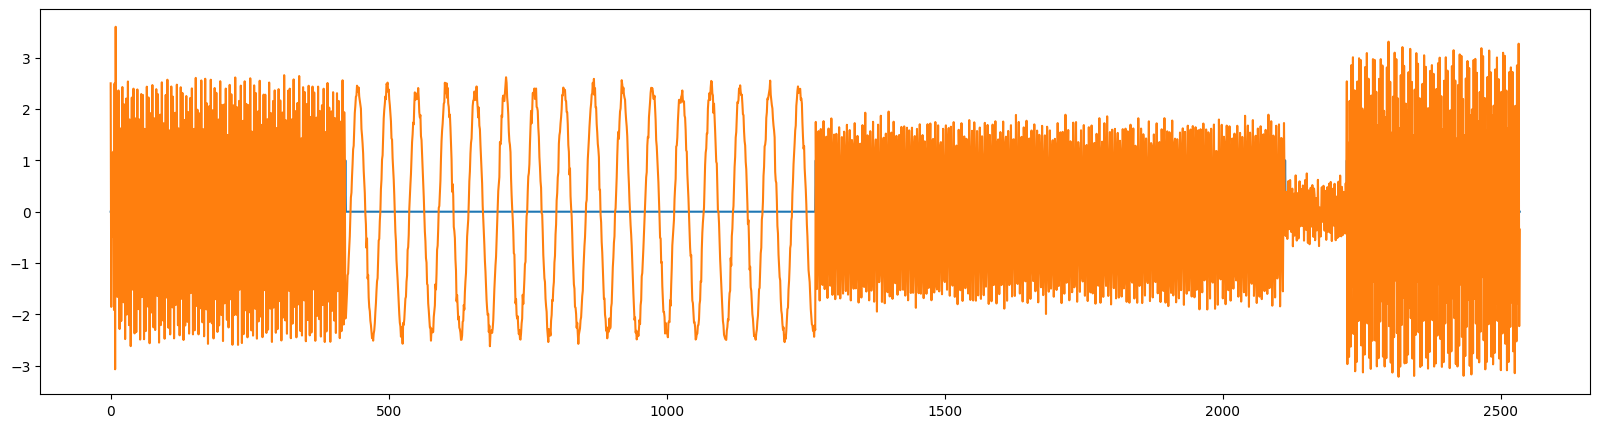

In [130]:
plt.figure(figsize=(20,5))
plt.plot(y)
plt.plot(x)

# Define NN

In [48]:
class EncoderLayer(nn.Module):
    def __init__(self,
                 sequence_length: int = 60,
                 n_layers: int = 6,
                 n_heads: int = 6,
                 dim_feedforward: int = 2048):
        super().__init__()
        
        self.activation = nn.Sigmoid()
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=sequence_length,
                                                   nhead=n_heads,
                                                   dim_feedforward=dim_feedforward,
                                                   norm_first=True,
                                                   batch_first=True)
        
        # decoder_layer = nn.TransformerDecoderLayer(d_model=sequence_length,
        #                                            nhead=n_heads,
        #                                            dim_feedforward=dim_feedforward,
        #                                            norm_first=True,
        #                                            batch_first=True)
        
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        # self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)

        # self.feed_forward_network = nn.Sequential(
        #     nn.Linear(400, 2048),
        #     nn.ReLU(),
        #     nn.Linear(2048, 512),
        #     nn.ReLU(),
        #     nn.Linear(512,1)
        # )
        
    @torch.inference_mode()
    def encode(self, x):
        """ Encode time series to a map of features.

        Arg:
            x: batch of raw time series data.
            
        Return:
            batch of encoded time series data.
        """
        return self.encoder(x)

    def forward(self, encoder_x):
        encoded_data = self.encoder(src=encoder_x)
        # decoded_data = self.decoder(memory=encoded_data,
        #                             tgt=encoder_x
        #                            )
        return self.activation(encoded_data)

# Helper Functions

2. **Padding Mask Purpose**:
   - The mask identifies which positions in the sequence (of length 32) are padding tokens for each batch item.
   - Shape starts as `(batch_size, seq_len)`.

3. **Mask Size**:
   - If `batch_size = 16` (each word as a batch item) and `seq_len = 32`:
     - Initial mask size: `(16, 32)`.
     - 0s for real tokens, 1s for padding (or vice versa, depending on your convention).
   - In attention, scores are `(batch_size, num_heads, seq_len, seq_len)` = `(16, num_heads, 32, 32)`.
     - Mask is reshaped to `(16, 1, 1, 32)` or broadcasted to `(16, num_heads, 32, 32)`.
     
 
### Final Answer
- **Correct `x_mask_padding` Size**: `(1, 6)` for `(batch_size, seq_len)`.
- Transform your `(6, 32)` mask to `(1, 6)` by reducing across features (e.g., `mask.all(dim=1).unsqueeze(0)`).

In [49]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout=0.1, max_len=1024, device: str = "cuda"):
        """ 
        Notes:
            d_model: number of features which reprsenet 1 token in NLP.
            max_len: length of the longest sequence which we can hold in memory by POSINCODING!
        
        Example:
            max_len 1024 means that max pos len is 1024 for time series which has 16 sequence where 
            each sequence length is 32. Like torch.Size([16, 1, 32]) # number sequences, batch, feature sequence
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1).to(torch.device(device))
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return x

In [50]:
class TimeSeries(Dataset):
    def __init__(self, time_series, sequence_length_nn: int = 60):
        self.time_series = time_series
        self.sequence_length_nn = sequence_length_nn
    
    def padding_sequence(self, data: np.array, d_model: int) -> np.array:
        not_dev_count = data.shape[0] % d_model
        if not_dev_count != 0:
            val_new_rows = int(np.ceil(data.shape[0] / d_model) * d_model - data.shape[0])
            data = np.pad(data, 
                     pad_width=((0), (val_new_rows)),  # Pad val_new_rows to sequence
                     mode='constant', 
                     constant_values=data[-1])
        return data
    
    def prepaire_sequence_to_encoding(self, data) -> torch.Tensor:
        """ Take padded numpy array to preapre it to torch.Tensor for NN
        """
        # aka time series points in one word
        number_of_words = data.shape[0] // self.sequence_length_nn
        return torch.Tensor(data).view(number_of_words, self.sequence_length_nn)
    
    def get_decoder_features(self, data: np.array) -> np.array:
        sst = SingularSequenceTransformer(n_components=2,
                                          sequence_window=32,
                                          lag=5,
                                          queue_window=10,
                                          is_fast_parameter_selection=False).fit(x_train=data, y_train=None)
        return sst.get_distances(target_array=data)
    
    def normalize_by_minmax(self, data: np.array) -> np.array:
        return (data-data.min())/(data.max()-data.min())
    

    def __getitem__(self, idx):
        y, x = self.time_series[idx]
        # x_sst = self.get_decoder_features(x)
        
        x = self.normalize_by_minmax(x)
        # x_sst = self.normalize_by_minmax(x_sst)
        padded_x = self.padding_sequence(x, d_model=self.sequence_length_nn)
        # padded_sst = self.padding_sequence(x_sst, d_model=self.sequence_length_nn)
        padded_y = self.padding_sequence(y, d_model=self.sequence_length_nn)
        
        x_prepaired = self.prepaire_sequence_to_encoding(padded_x)
        # sst_prepaired = self.prepaire_sequence_to_encoding(padded_sst)
        y_prepaired = self.prepaire_sequence_to_encoding(padded_y)
        # return torch.Tensor(x_prepaired), torch.Tensor(sst_prepaired), torch.Tensor([sum(y)])
        return torch.Tensor(x_prepaired), torch.Tensor(y_prepaired)

    def __len__(self):
        return len(self.time_series)

In [51]:
def add_probs_near_changepoint(cps: list):
    cps_new = []
    for index, val in enumerate(cps):
        cps_new.append(val)
        if val == 1:
            cps_new[index-1] = 0.85
            cps_new[index-2] = 0.7
            cps_new[index-3] = 0.5
            cps_new[index-4] = 0.3
            cps_new[index-5] = 0.1
            cps_new[index-6] = 1e-2
            cps_new[index-7] = 1e-3
        
    return np.array(cps_new)
        
def generate_some_training_data(number_datasets=1000,
                                cps_number_list=[9, 10, 11, 12, 13,14, 15],
                                length_data_list=[400],
                                min_max_std_list=[1, 5, 50, 100],
                                min_max_val_list=[5, 50, 100]) -> list:
    time_series = []
    for val in range(number_datasets):
        tmp_cps = random.choice(cps_number_list)
        tmp_length = random.choice(length_data_list)
        tmp_std = random.choice(min_max_std_list)
        tmp_val = random.choice(min_max_val_list)
        data_obj = SimpleRandomTimeSeries(length_data=tmp_length, cps_number=tmp_cps)
        y, x = data_obj.get(min_max_std=tmp_std, min_max_val=tmp_val)
#         y = add_probs_near_changepoint(cps=y)
        time_series.append((y, x))
    return time_series

# Define Data

In [52]:
# define encoder positional
encoding_pos = PositionalEncoding(d_model=60)

In [53]:
time_series_train = generate_some_training_data(number_datasets=5000)
time_series_valid = generate_some_training_data(number_datasets=1000)

In [54]:
train_dataset = TimeSeries(time_series=time_series_train)
valid_dataset = TimeSeries(time_series=time_series_valid)

In [55]:
x_0, y = next(iter(train_dataset))

In [56]:
x_0.shape, y.shape

(torch.Size([7, 60]), torch.Size([7, 60]))

In [57]:
train_loader = DataLoader(train_dataset, batch_size=64, num_workers=5, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, num_workers=5, pin_memory=True)

# Training pipeline

In [58]:
def train(model, loader):
    model.train()

    train_loss = 0

    for x_en, y in tqdm(loader, desc='Training'):
        x_en, y = x_en.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(encoding_pos(x_en))

        loss = loss_fn(output, y)

        train_loss += loss.item()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_loader)

    return train_loss

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()

    total_loss = 0

    for x_en, y in tqdm(loader, desc='Evaluation'):
        x_en, y = x_en.to(device), y.to(device)

        output = model(encoding_pos(x_en))

        loss = loss_fn(output, y)

        total_loss += loss.item()

    total_loss /= len(loader)

    return total_loss

In [59]:
def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()

    plt.show()

In [60]:
def whole_train_valid_cycle(model, num_epochs, title):
    train_loss_history, valid_loss_history = [], []

    for epoch in range(num_epochs):
        train_loss = train(model, train_loader)
        valid_loss = evaluate(model, valid_loader)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        clear_output(wait=True)

        plot_stats(
            train_loss_history, valid_loss_history,
            title
        )

# Setup train

In [61]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name())

cuda:0
NVIDIA GeForce RTX 3060 Laptop GPU


In [62]:
model = EncoderLayer().to(device)

In [63]:
optimizer = Adam(model.parameters(), lr=1e-5, weight_decay=0.6, foreach=False)
# loss_fn = nn.L1Loss(reduction="sum")
# loss_fn = nn.MSELoss(reduction="sum")
loss_fn = nn.BCELoss(reduction="sum")

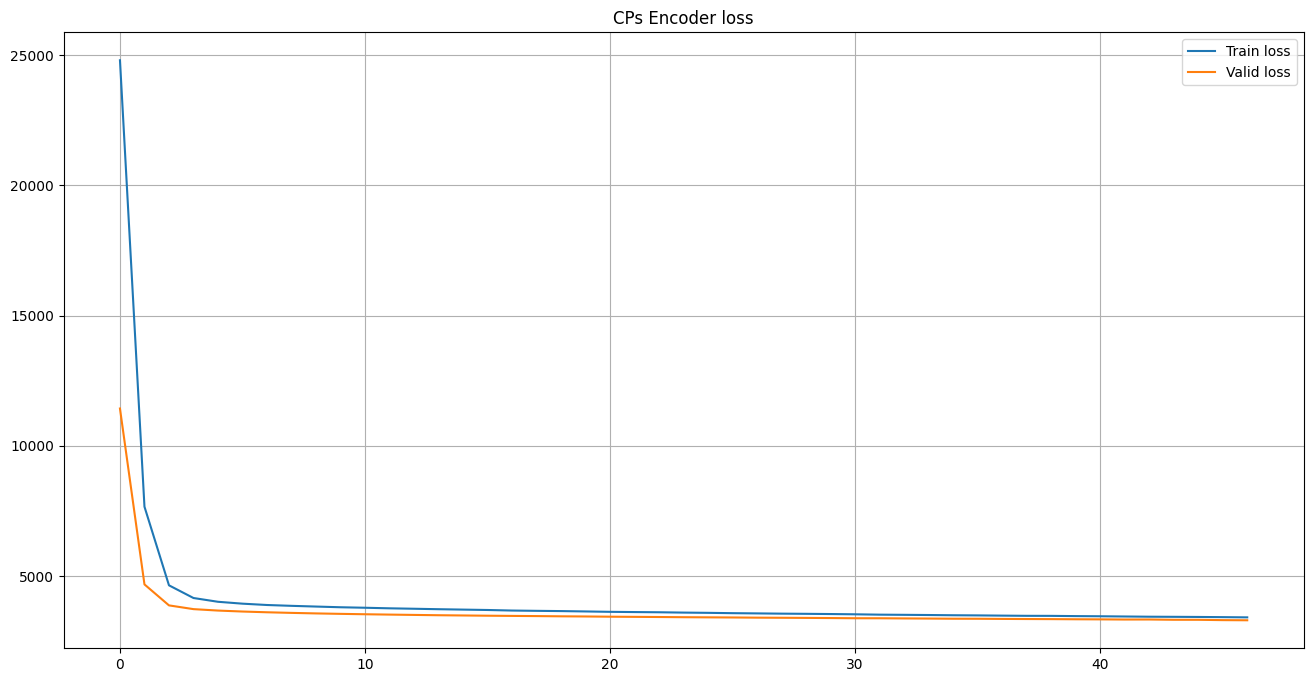

Training:  56%|████████████████████████████████████████████████████████████████                                                   | 44/79 [00:01<00:00, 38.24it/s]


KeyboardInterrupt: 

In [64]:
whole_train_valid_cycle(model, 50, 'CPs Encoder')

# Check results

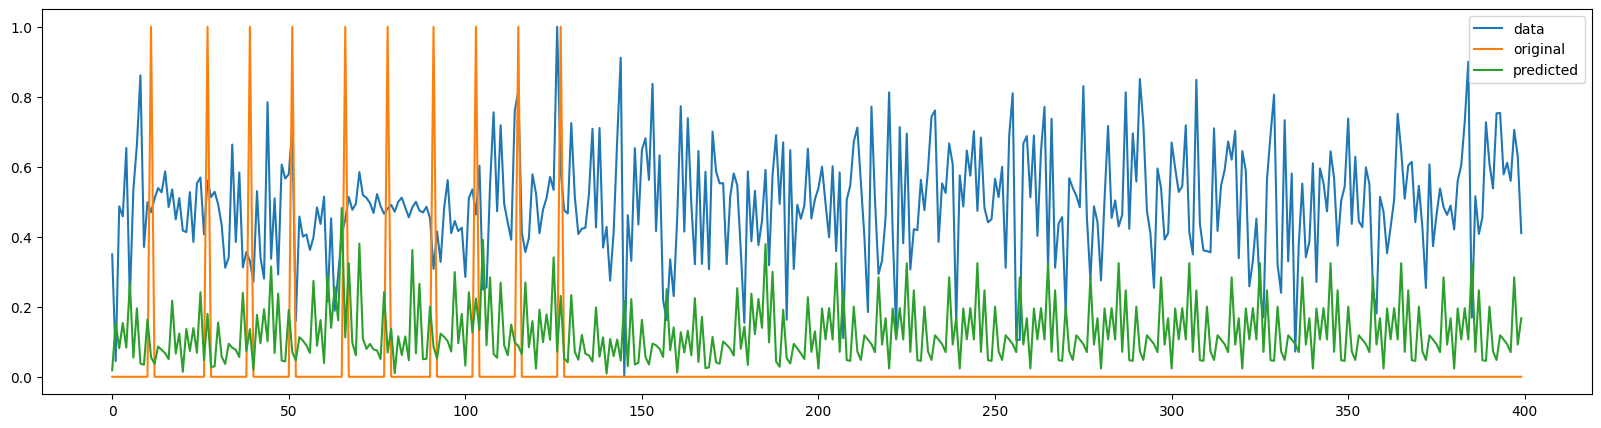

In [65]:
plt.figure(figsize=(20,5))
plt.plot(test_x.flatten(), label="data")
plt.plot(original_test, label='original')
plt.plot(array_out_numpy, label='predicted')
plt.legend()

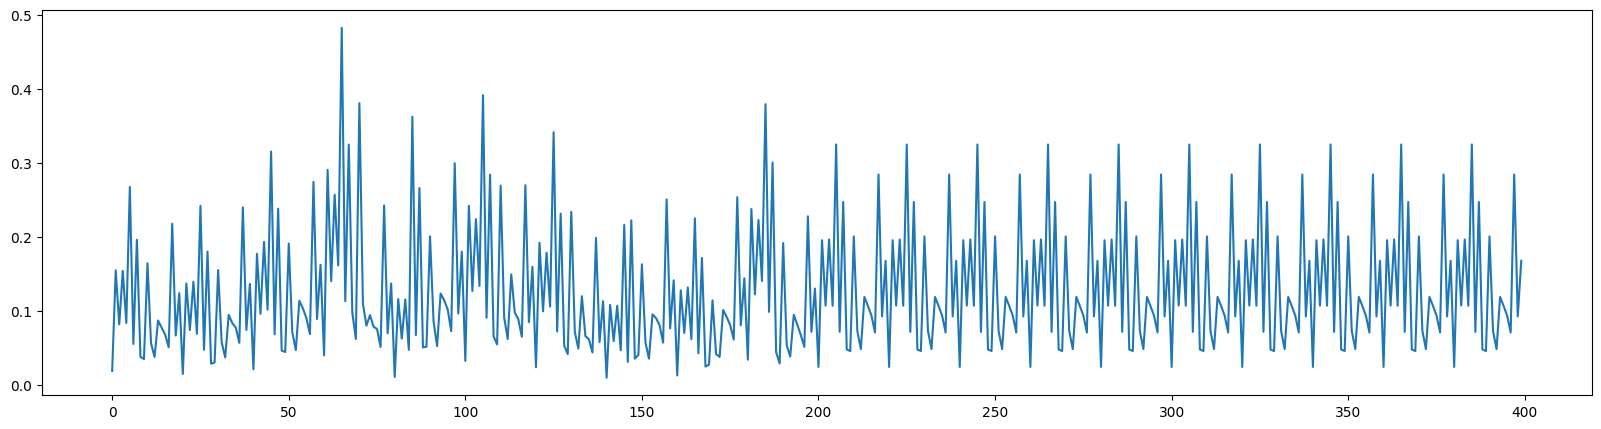

In [66]:
plt.figure(figsize=(20,5))
plt.plot(array_out_numpy)